## Laboratorium Sygnałów Medycznych


# Laboratorium Sygnałów Medycznych — Zajęcia 1
## Wprowadzenie do pracy z sygnałami w Pythonie

## Cel zajęć
Celem pierwszych zajęć jest zapoznanie się z podstawowymi narzędziami języka Python używanymi do:
- generowania sygnałów,
- wizualizacji danych,
- podstawowej analizy sygnałów biomedycznych,
- przygotowania środowiska do dalszych laboratoriów (EKG, EEG, EMG).

**Sygnał** - funkcja opisująca zmianę wielkości fizycznej w czasie.

Przykłady medyczne:
 - EKG — napięcie vs czas
 - EEG — aktywność mózgu
 - pulsoksymetria — absorpcja światła
 - EMG — aktywność mięśni

Sygnał ciągły w czasie:
$ x(t) $

Sygnał dyskretny:
$ x[n] $

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

### Przykład sygnału ciągłego

Text(0.5, 1.0, 'Sygnał ciągły $e^{-2t}$')

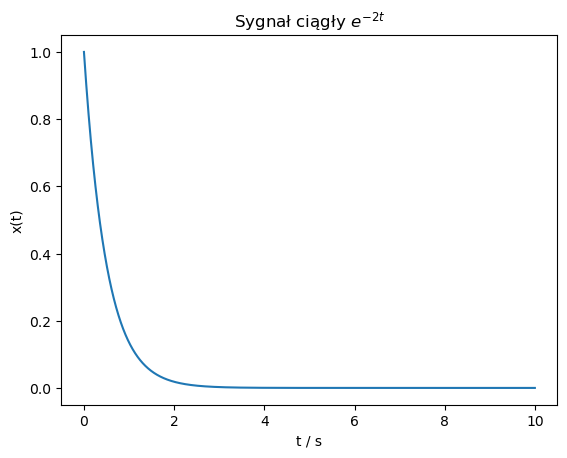

In [8]:
#sygnał pseudociągły
t = np.arange(0, 10, 0.001)
x = np.exp(-2*t)

#wizualizacja
plt.plot(t, x)
plt.xlabel('t / s')
plt.ylabel('x(t)')
plt.title('Sygnał ciągły $e^{-2t}$')

### Przykład sygnału dyskretnego

In [10]:
#Okres próbkowania [s]
Ts = 0.1

#częstotliwość próbkowania [Hz]
fs = 1/Ts

#czas trwania sygnału [s]
T = 10

In [12]:
#wektor czasu
td = np.arange(0, T, Ts)
xd = np.exp(-2*td)

Text(0.5, 1.0, 'Sygnał dyskretny $e^{-2t}$')

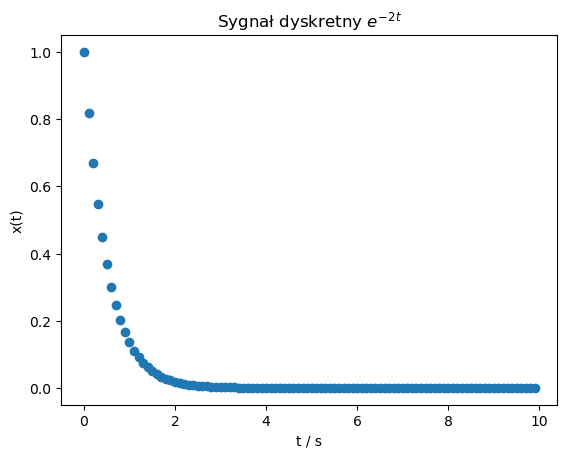

In [14]:
#wizualizacja sygnału
plt.plot(td,xd, 'o')
plt.xlabel('t / s')
plt.ylabel('x(t)')
plt.title('Sygnał dyskretny $e^{-2t}$')

### Przykład: sygnał harmoniczny + eksponencjalny

Text(0.5, 0, 't / s')

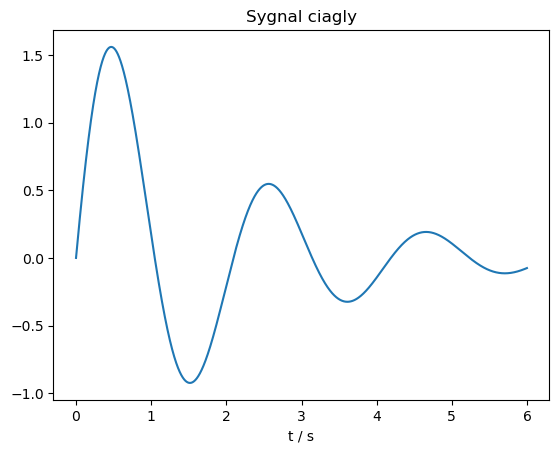

In [18]:
#sygnał pseudoanalogowy
t = np.arange(0,6,0.001)
x=2*np.exp(-0.5*t)*np.sin(3*t)
plt.plot(t,x)
plt.title('Sygnal ciagly')
plt.xlabel('t / s')

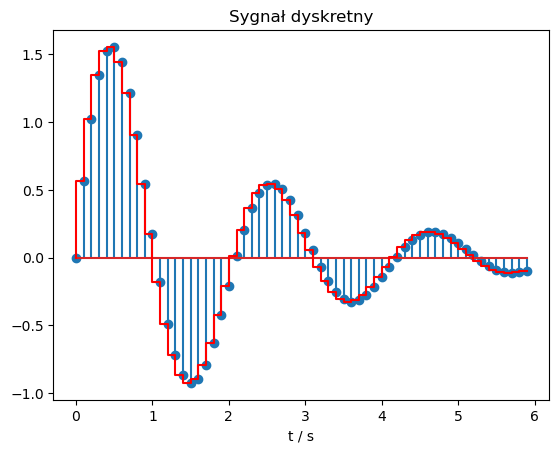

In [20]:
#reprezentacja dyskretna
fs = 10
Ts = 1/fs
td = np.arange(0,6,Ts)
xd=2*np.exp(-0.5*td)*np.sin(3*td)

plt.stem(td,xd)
plt.title('Sygnał dyskretny')
plt.xlabel('t / s')
plt.step(td,xd, color='red')

### Sygnały standardowe

In [47]:
t = np.linspace(0,1,500)

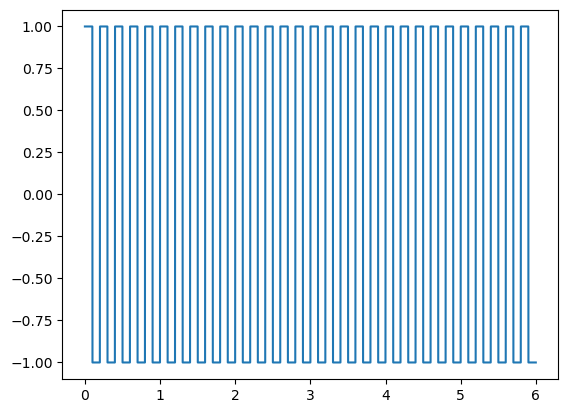

In [24]:
#sygnał prostokątny
square = signal.square(2*np.pi*5*t)
plt.plot(t, square)

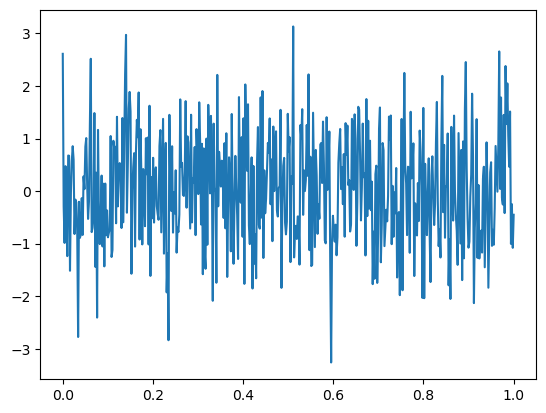

In [51]:
#Szum biały
noise = np.random.randn(len(t))
plt.plot(t, noise)  

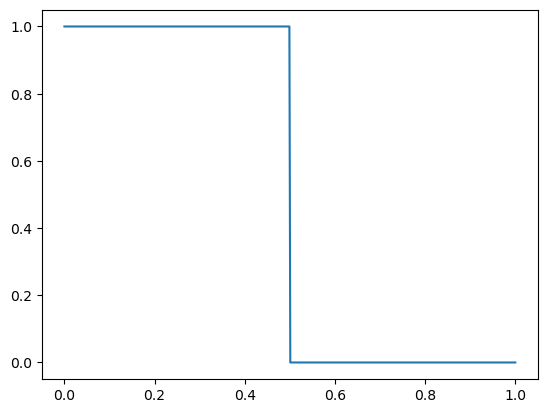

In [53]:
#impuls prostokątny
rect_pulse = np.zeros(len(t))
rect_pulse[:len(t)//2] = 1
plt.plot(t, rect_pulse)

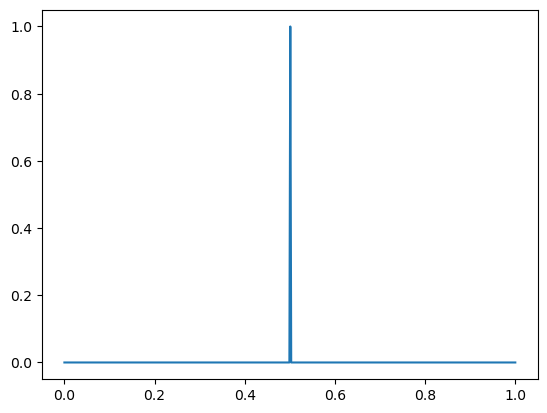

In [55]:
#delta diraca
dirac = signal.unit_impulse(len(t), 'mid')
plt.plot(t, dirac)

### Symulowanie realistycznego sygnału - szum

In [62]:
#sygnał bez szumu
x = (
    np.sin(2*np.pi*5*t) +
    0.5*np.sin(2*np.pi*20*t)
)
#generowanie szumu o rozkładzie normalnym
noise = np.random.normal(0, 0.3, len(t))

#sygnał zaszumiony
x_noisy = x + noise

Text(0, 0.5, 'x(t)')

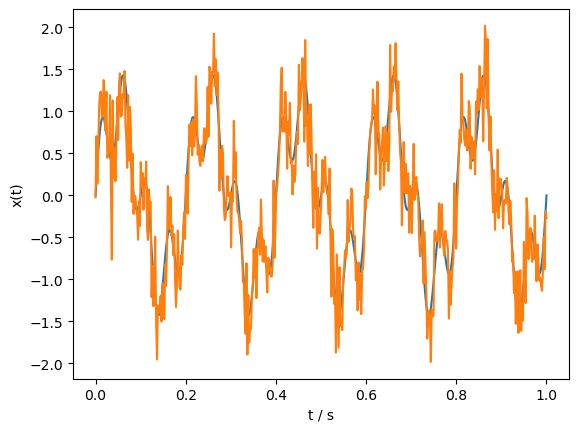

In [68]:
plt.plot(t, x, t, x_noisy)
plt.xlabel('t / s')
plt.ylabel('x(t)')